In [ ]:
import os
import numpy as np
import d3rlpy
import csv
import matplotlib.pyplot as plt

def read_Episodes(baseFolder):
    episodes = []
    for filename in sorted(os.listdir(baseFolder)):
        filePath = os.path.join(baseFolder, filename)
        episode = []
        with open(filePath, "r", newline="") as file:
            reader = csv.reader(file)
            next(reader)  # Skip header row
            for row in reader:
                observation = [float(epi) for epi in row]
                episode.append(observation)
            episodes.append(episode)
    return episodes

def load_models_from_training(training_dir):
    models = []
    model_files = sorted([f for f in os.listdir(training_dir) if f.endswith('.d3')])
    
    if len(model_files) > 10:
        step = (len(model_files) - 1) / 9
        selected_indices = [int(i * step) for i in range(9)]
        selected_indices.append(len(model_files) - 1)
        selected_indices = sorted(list(set(selected_indices)))
        model_files = [model_files[i] for i in selected_indices]
    for i,model_file in enumerate(model_files):
        model_path = os.path.join(training_dir, model_file)
        try:
            model = d3rlpy.load_learnable(model_path)
            models.append(((str(i)+model_file), model)) 
        except Exception as e:
            print(f"Error loading {model_file}: {e}")
    return models


Processing algorithm: BCQ_20260115190126
Keine Differenzen für 0model_1000.d3 (BCQ_20260115190126) zum Plotten vorhanden. Fehlerhafte Episoden: 5


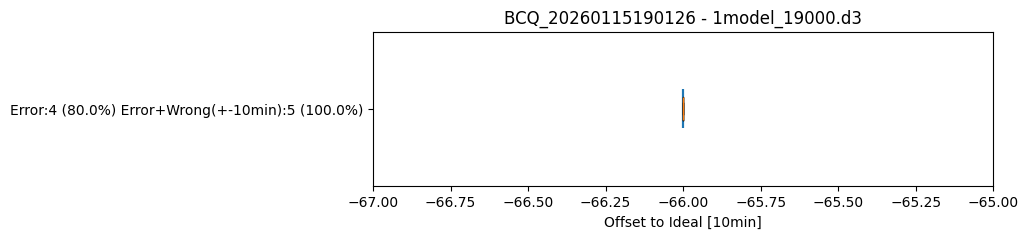

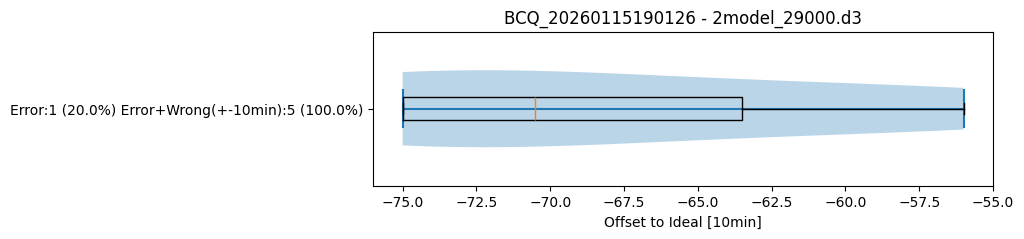

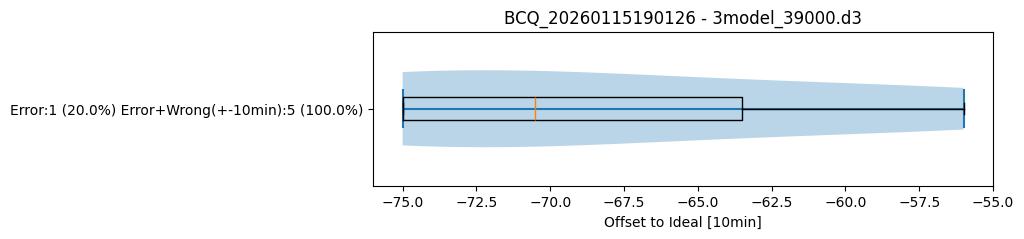

KeyboardInterrupt: 

In [ ]:
#ToDo neues Datenset erzeugen mit nur idealen episoden um herauszufinden wie gut die Modelle wirklich sind 
#ToDo aus den real dAten muss auch ein datensatz gemacht werden um zu schauen wie gut die Modelle auf real daten sind
#      Dabei auf die Werte achten muss seleb Form wie bei den Trainingsdaten haben

#Das Modell muss integriert werden um nach jeder Prediction entsprechend den Drain und die time since last neu zu 
# berechnen ahnahd der predicition um so die nächste prediction zu verbessern. Die Ideal linie mus auch neu berehcnet werden. (perekter reward)


# ==== Hauptfunktion ====
base_dir = "test logs"  # Passe ggf. an
#testEpisode = "../data/episFormula/3.2 test für 2.0/"  # Passe ggf. an
testEpisode = "../data/episFormula/test"  # Passe ggf. an


if os.path.exists(base_dir):
    algorithm_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    for algorithm_name in algorithm_dirs:
        # Arrays für spätere Auswertung
        model_names = []
        algo_names = [] 
        error_rates = []
        not_identified_rates = []
        total_error_rates = []
        algorithm_path = os.path.join(base_dir, algorithm_name)
        print(f"\nProcessing algorithm: {algorithm_name}")
        models = load_models_from_training(algorithm_path)
        if not models:
            print(f"No models found in {algorithm_path}")
            continue
        episodes = read_Episodes(testEpisode)
        for i, (model_name, model) in enumerate(models):
            soll_ist_diff = []
            totalError = 0
            not_identified = 0
            wrongEpisode = 0
            for samples in episodes:
                prediction = []
                for sample in samples:
                    obs = np.array([sample[:-3]])
                    try:
                        pred = model.predict(obs)[0]
                    except Exception as e:
                        pred = 0
                    prediction.append(pred)
                soll_idx = next((i for i, v in enumerate([sample[-1] for sample in samples]) if v > 0), None)
                ist_idx = next((i for i, v in enumerate(prediction) if v <= 10), None)
                if  ist_idx is None:
                    totalError += 1
                elif soll_idx is None:
                    wrongEpisode += 1
                    Warning("Soll Index nicht gefunden in Episode")
                else:
                    abweichung = ist_idx + 1 - soll_idx
                    soll_ist_diff.append(abweichung)
                    if not (-1 <= abweichung <= 1):
                        not_identified += 1
            n_valid = len(episodes) - wrongEpisode
            if len(soll_ist_diff) > 0 and n_valid > 0:
                wrong_predicted = ((totalError + not_identified) / n_valid) * 100
                error_percent = (totalError / n_valid) * 100
                not_identified_percent = (not_identified / n_valid) * 100
                # Arrays befüllen
                model_names.append(model_name)
                algo_names.append(algorithm_name)
                error_rates.append(error_percent)
                not_identified_rates.append(not_identified_percent)
                total_error_rates.append(wrong_predicted)
                plt.figure(figsize=(8,2))
                plt.violinplot(soll_ist_diff, vert=False)
                plt.boxplot(soll_ist_diff, vert=False, tick_labels=[f"Error:{totalError} ({error_percent:.1f}%) Error+Wrong(+-10min):{not_identified+totalError} ({wrong_predicted:.1f}%)"])
                plt.title(f"{algorithm_name} - {model_name}")
                plt.xlabel("Offset to Ideal [10min]")
                plt.xlim(min(soll_ist_diff) - 1, max(soll_ist_diff) + 1)
                plt.show()
            else:
                print(f"Keine Differenzen für {model_name} ({algorithm_name}) zum Plotten vorhanden. Fehlerhafte Episoden: {totalError}")

        # Zusammenfassende Visualisierung
        import pandas as pd
        plt.figure(figsize=(12,6))
        #reset parameters for
        summary_df = pd.DataFrame({
            "Algorithmus": algo_names,
            "Modell": model_names,
            "Error %": error_rates,
            "NotIdentified %": not_identified_rates,
            "Total Error %": total_error_rates
        })
        x = np.arange(len(summary_df))
        width = 0.25
        plt.bar(x - width, summary_df["Error %"], width=width, label="Error %")
        plt.bar(x, summary_df["NotIdentified %"], width=width, label="NotIdentified %")
        plt.bar(x + width, summary_df["Total Error %"], width=width, label="Error+NotIdentified %")
        plt.xticks(x, [f"{a}\n{m}" for a, m in zip(summary_df["Algorithmus"], summary_df["Modell"])], rotation=45, ha="right")
        plt.ylabel("Rate [%]")
        plt.title("Fehlerraten pro Modell und Algorithmus")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print(f"Directory {base_dir} not found!")

c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\d3rlpy\torch_utility.py:431: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpt = torch.load(f, map_locatio

Modell geladen: model_99000.d3
Anzahl geladener Episoden: 5

=== Testergebnisse ===
Modell: model_99000.d3
Test-Episoden: 5
Gültige Episoden: 5
Fehlerhafte Episoden: 0
Fehlerrate (Prediction Error): 20.00%
Nicht erkannt (±10min): 60.00%
Gesamtfehlerrate: 80.00%
Mittlere Abweichung: -53.75 ±31.82 in]


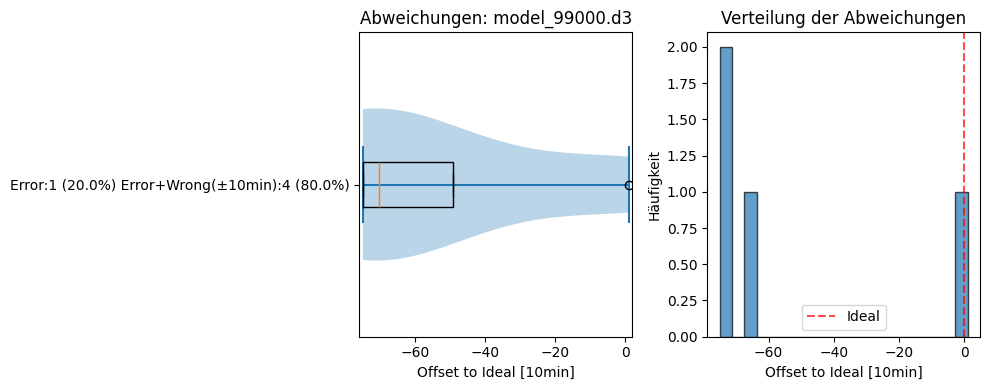

In [3]:
def test_csv_folder_against_latest_model(csv_folder, model_folder):
    """
    Testet CSV-Dateien aus einem Ordner gegen das neueste Modell in einem Modell-Ordner.
    
    Args:
        csv_folder (str): Pfad zum Ordner mit CSV-Dateien (Episoden)
        model_folder (str): Pfad zum Ordner mit Modellen (.d3 Dateien)
    
    Returns:
        dict: Dictionary mit Testergebnissen
    """
    
    # Lade das neueste Modell
    model_files = sorted([f for f in os.listdir(model_folder) if f.endswith('.d3')])
    if not model_files:
        print(f"Keine Modelle in {model_folder} gefunden!")
        return None
    
    latest_model_file = model_files[-1]  # Nimmt das letzte (neueste) Modell
    model_path = os.path.join(model_folder, latest_model_file)
    
    try:
        model = d3rlpy.load_learnable(model_path)
        print(f"Modell geladen: {latest_model_file}")
    except Exception as e:
        print(f"Fehler beim Laden des Modells {latest_model_file}: {e}")
        return None
    
    # Lade die Test-Episoden
    try:
        episodes = read_Episodes(csv_folder)
        print(f"Anzahl geladener Episoden: {len(episodes)}")
    except Exception as e:
        print(f"Fehler beim Laden der Episoden aus {csv_folder}: {e}")
        return None
    
    # Teste das Modell gegen die Episoden
    results = {
        'model_name': latest_model_file,
        'model_path': model_path,
        'csv_folder': csv_folder,
        'total_episodes': len(episodes),
        'soll_ist_differences': [],
        'total_errors': 0,
        'not_identified': 0,
        'wrong_episodes': 0
    }
    
    for episode_idx, samples in enumerate(episodes):
        prediction = []
        
        # Vorhersagen für alle Samples in der Episode
        for sample in samples:
            obs = np.array([sample[:-3]])  # Alle Features außer den letzten 3 (reward, terminal, ?)
            try:
                pred = model.predict(obs)[0]
            except Exception as e:
                pred = 0
            prediction.append(pred)
        
        # Finde den Soll-Index (wo terminal=1 oder reward>0?)
        soll_idx = next((i for i, v in enumerate([sample[-1] for sample in samples]) if v > 0), None)
        
        # Finde den Ist-Index (erste Vorhersage <= 10)
        ist_idx = next((i for i, v in enumerate(prediction) if v <= 10), None)
        
        if ist_idx is None:
            results['total_errors'] += 1
        elif soll_idx is None:
            results['wrong_episodes'] += 1
            print(f"Warnung: Soll-Index nicht gefunden in Episode {episode_idx}")
        else:
            abweichung = ist_idx + 1 - soll_idx
            results['soll_ist_differences'].append(abweichung)
            if not (-1 <= abweichung <= 1):
                results['not_identified'] += 1
    
    # Berechne Fehlerraten
    n_valid = results['total_episodes'] - results['wrong_episodes']
    if n_valid > 0:
        results['error_rate'] = (results['total_errors'] / n_valid) * 100
        results['not_identified_rate'] = (results['not_identified'] / n_valid) * 100
        results['total_error_rate'] = ((results['total_errors'] + results['not_identified']) / n_valid) * 100
    else:
        results['error_rate'] = 0
        results['not_identified_rate'] = 0
        results['total_error_rate'] = 0
    
    # Ausgabe der Ergebnisse
    print(f"\n=== Testergebnisse ===")
    print(f"Modell: {results['model_name']}")
    print(f"Test-Episoden: {results['total_episodes']}")
    print(f"Gültige Episoden: {n_valid}")
    print(f"Fehlerhafte Episoden: {results['wrong_episodes']}")
    print(f"Fehlerrate (Prediction Error): {results['error_rate']:.2f}%")
    print(f"Nicht erkannt (±10min): {results['not_identified_rate']:.2f}%")
    print(f"Gesamtfehlerrate: {results['total_error_rate']:.2f}%")
    
    if results['soll_ist_differences']:
        print(f"Mittlere Abweichung: {np.mean(results['soll_ist_differences']):.2f} ±{np.std(results['soll_ist_differences']):.2f} [10min]")
    
    return results

def visualize_test_results(results):
    """
    Visualisiert die Testergebnisse.
    
    Args:
        results (dict): Rückgabe von test_csv_folder_against_latest_model
    """
    if results is None or not results['soll_ist_differences']:
        print("Keine Daten zum Visualisieren vorhanden.")
        return
    
    soll_ist_diff = results['soll_ist_differences']
    
    # Violin/Box Plot
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.violinplot(soll_ist_diff, vert=False)
    plt.boxplot(soll_ist_diff, vert=False, 
                tick_labels=[f"Error:{results['total_errors']} ({results['error_rate']:.1f}%) "
                           f"Error+Wrong(±10min):{results['total_errors']+results['not_identified']} "
                           f"({results['total_error_rate']:.1f}%)"])
    plt.title(f"Abweichungen: {results['model_name']}")
    plt.xlabel("Offset to Ideal [10min]")
    plt.xlim(min(soll_ist_diff) - 1, max(soll_ist_diff) + 1)
    
    # Histogramm
    plt.subplot(1, 2, 2)
    plt.hist(soll_ist_diff, bins=20, alpha=0.7, edgecolor='black')
    plt.title("Verteilung der Abweichungen")
    plt.xlabel("Offset to Ideal [10min]")
    plt.ylabel("Häufigkeit")
    plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Ideal')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Beispiel für die Verwendung:
results = test_csv_folder_against_latest_model("../data/episFormula/test", "test logs/PLAS_20260116030234")
visualize_test_results(results)

In [27]:
def plot_single_day_progression(episode, episode_index, models, model_names):
    """
    Plottet den Tagesverlauf einer einzelnen Episode.
    
    Args:
        episode (list): Episode Daten
        episode_index (int): Index der Episode
        model: Das geladene Modell
        model_name (str): Name des Modells
    """
    
    # Extrahiere Daten aus der Episode
    abstimes = [sample[1] for sample in episode]  # abstime column (absolute time in minutes)
    times = [sample[2] for sample in episode]  # time column (relative time)
    time_to_irri_actual = [sample[7] for sample in episode]  # timeToIrri column
    terminals = [sample[9] for sample in episode]  # terminal column
    
    # Generiere Vorhersagen
    MultiPredictions = []
    for sample in episode:
        obs = np.array([sample[:-3]])  # Alle Features außer den letzten 3
        for model in models:
            predictions = []
            try:
                pred = model.predict(obs)[0]
                # Stelle sicher, dass pred ein Skalar ist
                if isinstance(pred, np.ndarray):
                    pred = pred.item() if pred.size == 1 else pred[0]
                elif hasattr(pred, '__len__') and len(pred) > 0:
                    pred = pred[0]
            except Exception as e:
                pred = 0
            predictions.append(float(pred))
            MultiPredictions.append(predictions)
    
    # Finde Bewässerungszeitpunkte
    irrigation_times = [abstimes[i] for i, terminal in enumerate(terminals) if terminal > 0]
    
    # Erstelle das Diagramm
    plt.figure(figsize=(15, 8))
    
    # Subplot 1: timeToIrri Vergleich
    plt.subplot(2, 1, 1)
    plt.plot(abstimes, time_to_irri_actual, 'b-', linewidth=2, label='Tatsächliche timeToIrri')
    for i, pred in enumerate(MultiPredictions):
        plt.plot(abstimes, pred, 'r--', linewidth=2, alpha=0.7, label=model_names[i])
    
    # Markiere Bewässerungszeitpunkte
    for irr_time in irrigation_times:
        plt.axvline(x=irr_time, color='green', linestyle=':', alpha=0.7, linewidth=2)
    
    plt.xlabel('Absolute Zeit (Minuten)')
    plt.ylabel('Zeit bis Bewässerung (Minuten)')
    plt.title(f'Tag {episode_index + 1}: timeToIrri vs. Modellvorhersage (mit abstime)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Differenz zwischen Vorhersage und Realität
    plt.subplot(2, 1, 2)
    for i, pred in enumerate(MultiPredictions):
        differences = [float(p) - float(actual) for p, actual in zip(pred, time_to_irri_actual)]
        plt.plot(abstimes, differences, linewidth=1.5, alpha=0.8, label=f'Differenz {model_names[i]}')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    
    # Markiere Bewässerungszeitpunkte auch hier
    for irr_time in irrigation_times:
        plt.axvline(x=irr_time, color='green', linestyle=':', alpha=0.7, linewidth=2)
    
    plt.xlabel('Absolute Zeit (Minuten)')
    plt.ylabel('Differenz (Vorhersage - Tatsächlich)')
    plt.title('Differenz zwischen Modellvorhersage und tatsächlicher timeToIrri')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return {
        'episode_index': episode_index,
        'num_irrigations': len(irrigation_times),
        'num_datapoints': len(episode)
    }

def plot_all_daily_progressions(csv_folder, models_folder, max_episodes=None):
    """
    Plottet den Tagesverlauf für alle Episoden mit separaten Diagrammen pro Tag.
    
    Args:
        csv_folder (str): Pfad zum Ordner mit CSV-Dateien
        models_folder (str): Pfad zum Ordner mit Modellen
        max_episodes (int): Maximale Anzahl von Episoden zu plotten (None für alle)
    """
    
    # Lade das neueste Modell
    models = []
    models_Names = []
    if isinstance(models_folder, list):
        for model_folder in models_folder:
            model_files = sorted([f for f in os.listdir(model_folder) if f.endswith('.d3')])
            if not model_files:
                print(f"Keine Modelle in {model_folder} gefunden!")
                continue
            
            latest_model_file = model_files[-1]
            models_Names.append(latest_model_file)
            model_path = os.path.join(model_folder, latest_model_file)
            
            try:
                model = d3rlpy.load_learnable(model_path)
                models.append(model)
                print(f"Modell geladen: {latest_model_file} aus {model_folder}")
            except Exception as e:
                print(f"Fehler beim Laden des Modells: {e}")
                continue

    # Lade die Episoden
    episodes = read_Episodes(csv_folder)
    total_episodes = len(episodes)
    
    # Begrenze die Anzahl wenn gewünscht
    if max_episodes is not None:
        episodes = episodes[:max_episodes]
        print(f"Plotte die ersten {len(episodes)} von {total_episodes} verfügbaren Episoden")
    else:
        print(f"Plotte alle {total_episodes} verfügbaren Episoden")
    
    # Sammle Statistiken über alle Tage
    all_stats = []
    
    # Plotte jeden Tag separat
    for episode_index, episode in enumerate(episodes):
        print(f"\nPlotte Tag {episode_index + 1} von {len(episodes)}...")
        stats = plot_single_day_progression(episode, episode_index, models, models_Names)
        all_stats.append(stats)

    return all_stats

def plot_daily_progression_with_predictions(csv_folder, model_folder, episode_index=0):
    """
    Plottet den Tagesverlauf einer Episode mit timeToIrri und Modellvorhersagen.
    (Behält die ursprüngliche Funktion für Rückwärtskompatibilität)
    
    Args:
        csv_folder (str): Pfad zum Ordner mit CSV-Dateien
        model_folder (str): Pfad zum Ordner mit Modellen
        episode_index (int): Index der Episode die geplottet werden soll
    """
    
    # Lade das neueste Modell
    model_files = sorted([f for f in os.listdir(model_folder) if f.endswith('.d3')])
    if not model_files:
        print(f"Keine Modelle in {model_folder} gefunden!")
        return
    
    latest_model_file = model_files[-1]
    model_path = os.path.join(model_folder, latest_model_file)
    
    try:
        model = d3rlpy.load_learnable(model_path)
        print(f"Modell geladen: {latest_model_file}")
    except Exception as e:
        print(f"Fehler beim Laden des Modells: {e}")
        return
    
    # Lade die Episoden
    episodes = read_Episodes(csv_folder)
    if episode_index >= len(episodes):
        print(f"Episode {episode_index} nicht gefunden. Verfügbare Episoden: 0-{len(episodes)-1}")
        return
    
    episode = episodes[episode_index]
    return plot_single_day_progression(episode, episode_index, model, latest_model_file)

# Verwende die Funktion mit Ihren Daten
#plot_daily_progression_with_predictions("../data/episFormula/test", "test logs/PLAS_20260116030234", episode_index=0)

Plotte die ersten 5 von 5 verfügbaren Episoden

Plotte Tag 1 von 5...


C:\Users\NilsWindows\AppData\Local\Temp\ipykernel_8368\187018881.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


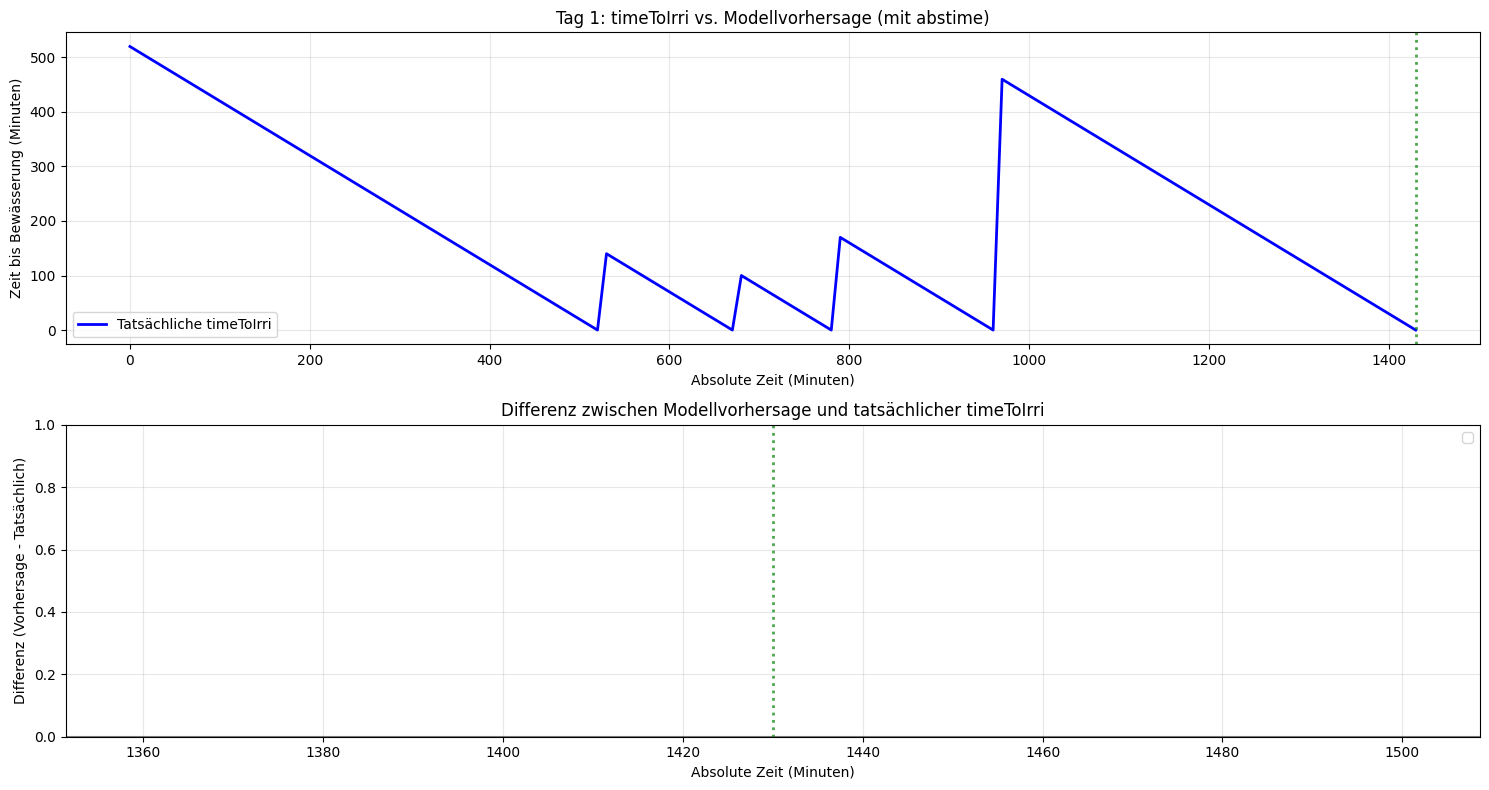


Plotte Tag 2 von 5...


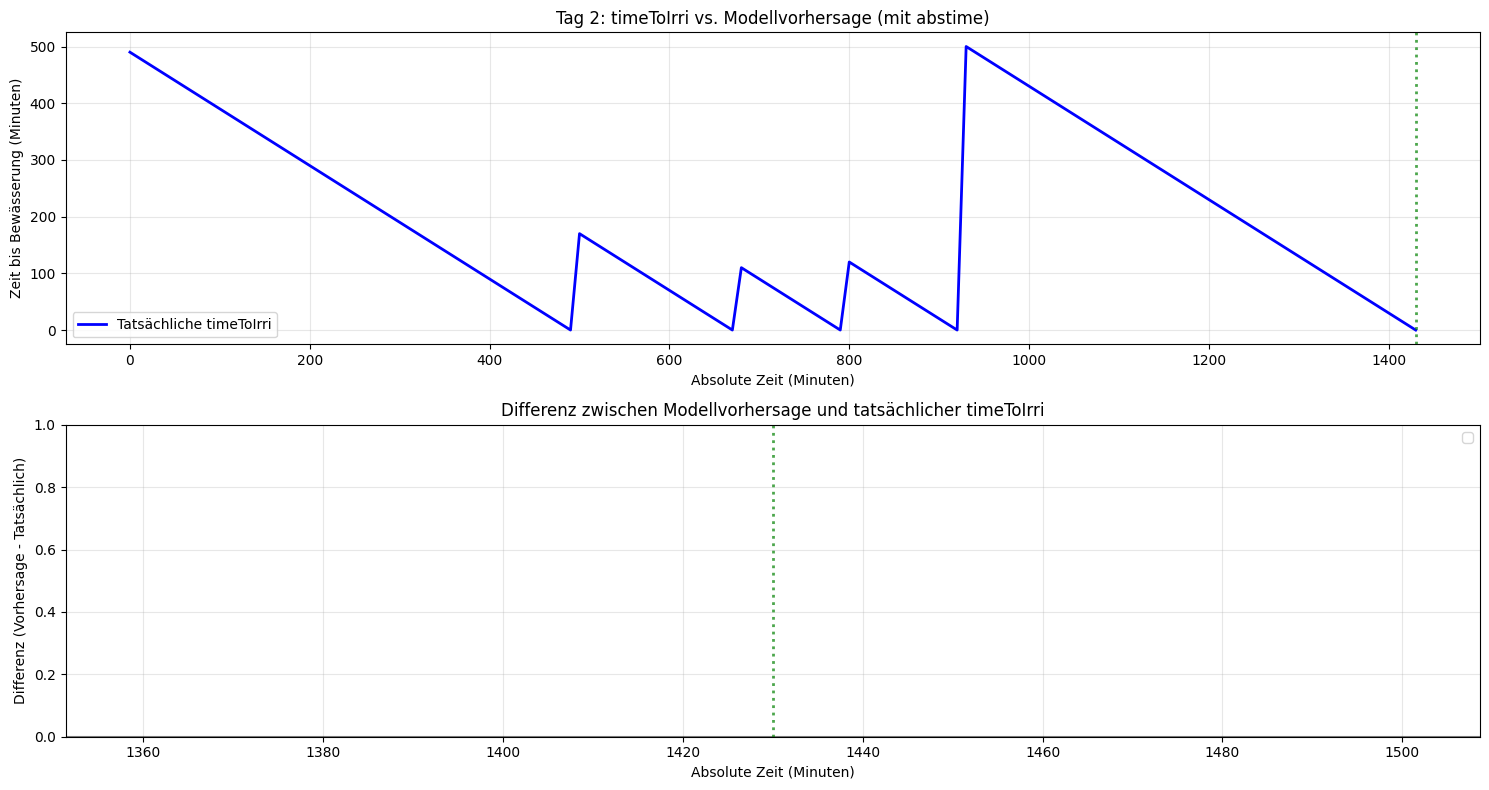


Plotte Tag 3 von 5...


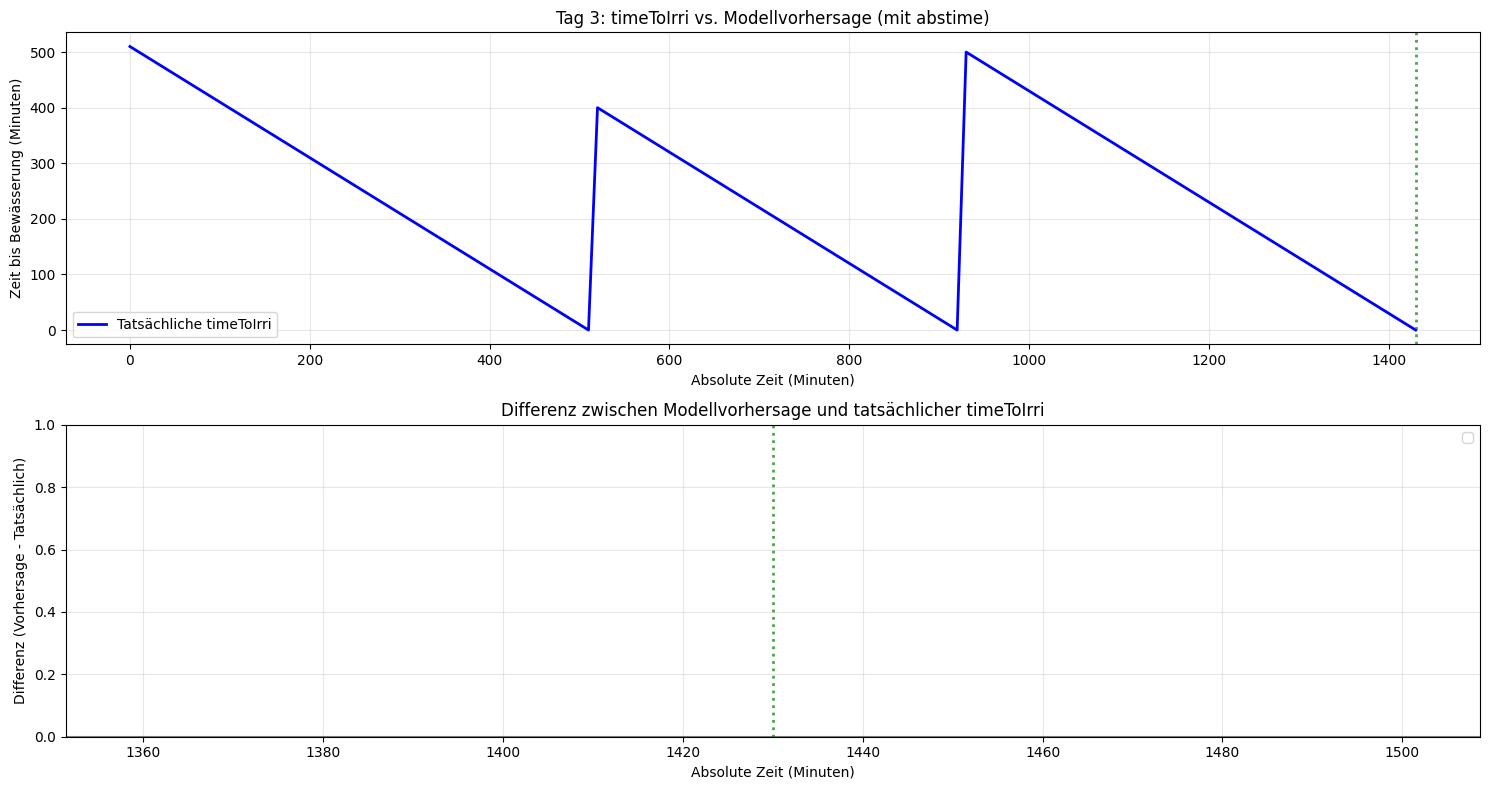


Plotte Tag 4 von 5...


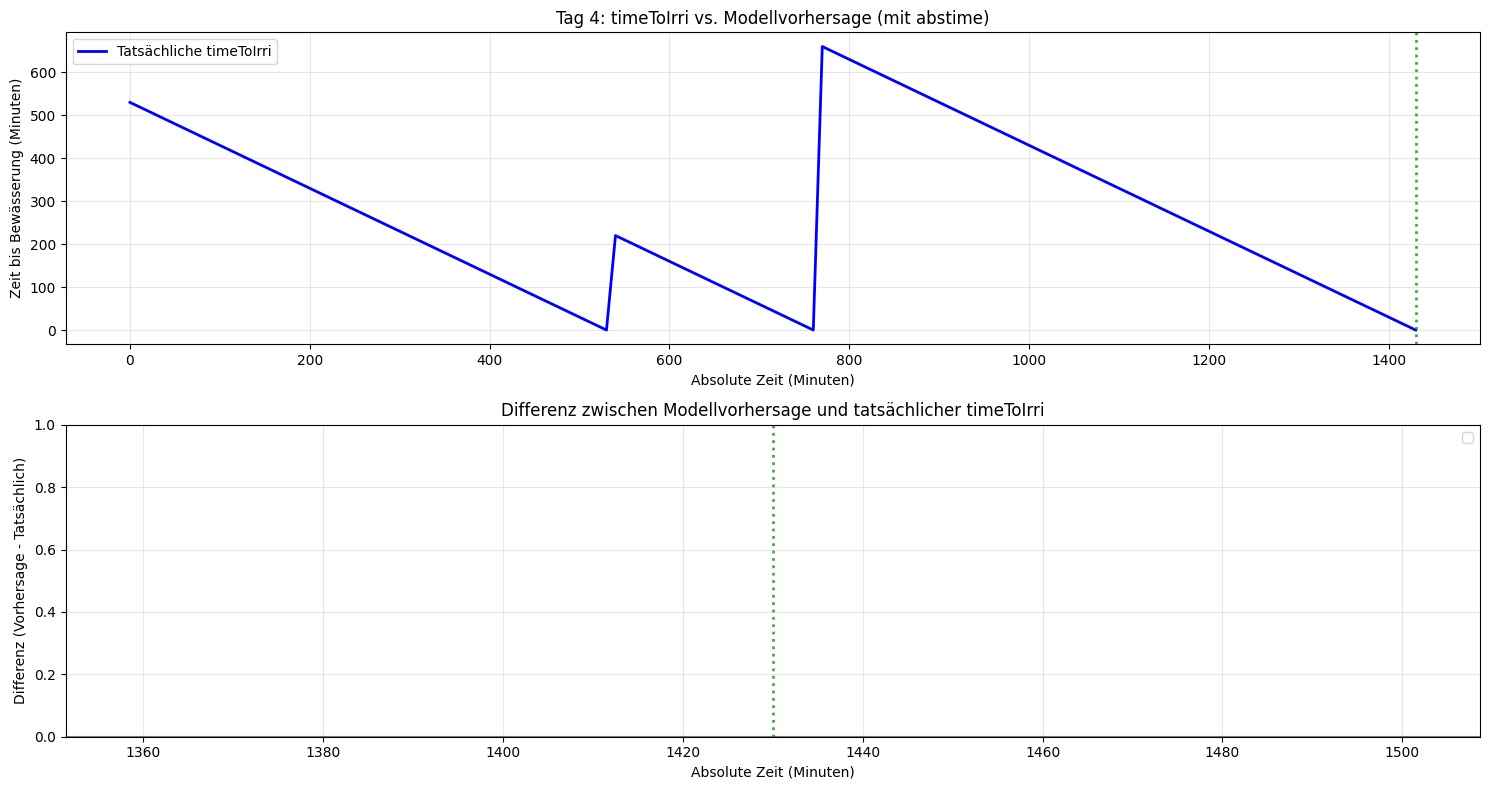


Plotte Tag 5 von 5...


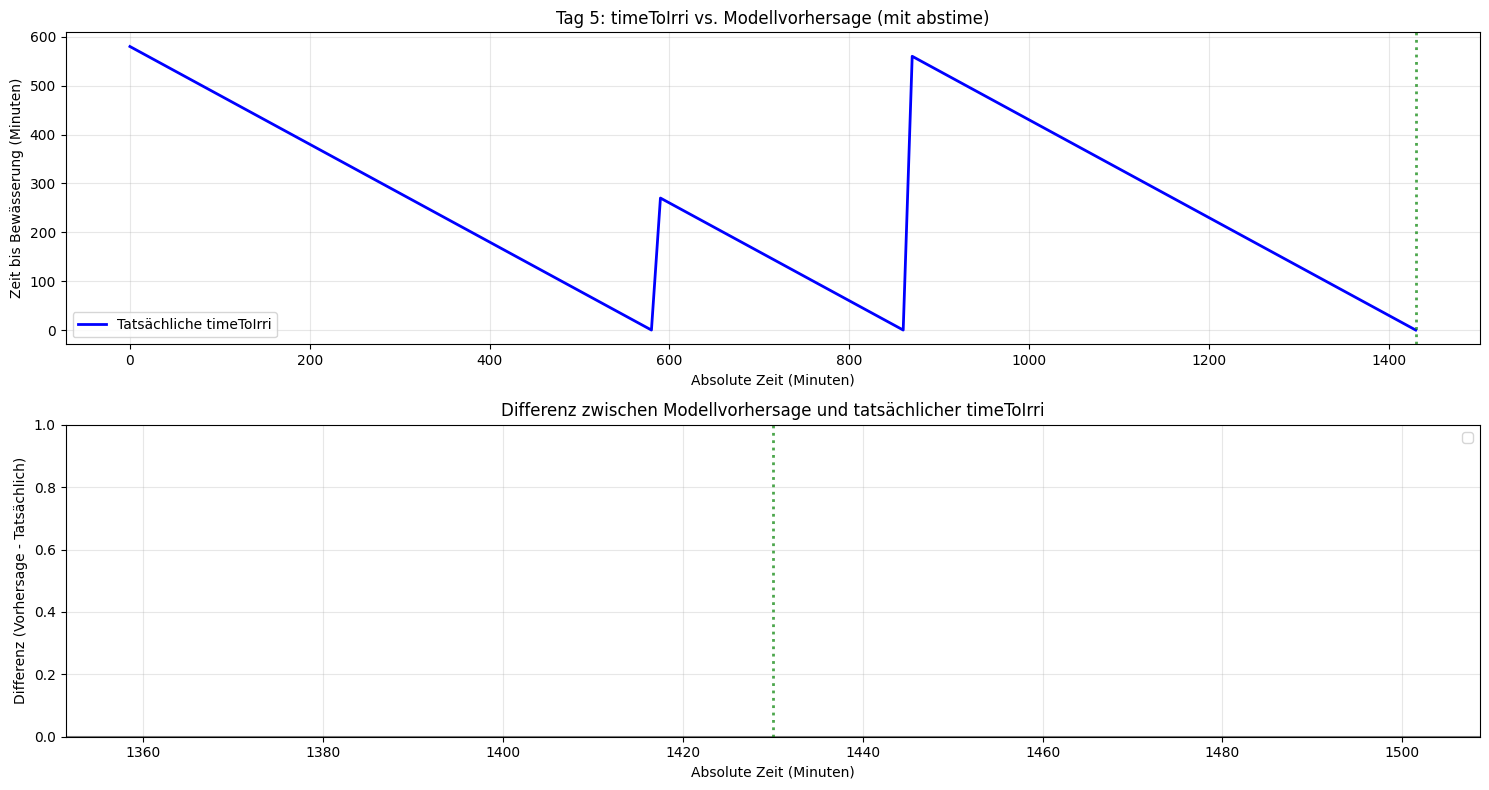

In [28]:
# Plotte alle verfügbaren Tage (begrenzt auf die ersten 10 für bessere Performance)
all_stats = plot_all_daily_progressions("../data/episFormula/test", "test logs", max_episodes=10)

In [14]:
def load_all_models_from_folder(model_folder):
    """
    Lädt alle Modelle aus einem Ordner.
    
    Args:
        model_folder (str): Pfad zum Ordner mit Modellen (.d3 Dateien)
    
    Returns:
        list: Liste von Tupeln (model_name, model_object)
    """
    models = []
    model_files = sorted([f for f in os.listdir(model_folder) if f.endswith('.d3')])
    
    print(f"Gefundene Modelle: {len(model_files)}")
    
    for model_file in model_files:
        model_path = os.path.join(model_folder, model_file)
        try:
            model = d3rlpy.load_learnable(model_path)
            models.append((model_file, model))
            print(f"✓ Modell geladen: {model_file}")
        except Exception as e:
            print(f"✗ Fehler beim Laden von {model_file}: {e}")
    
    return models

def plot_episode_with_all_models(episode, episode_index, models, csv_folder_name):
    """
    Plottet eine Episode mit allen Modellvorhersagen.
    
    Args:
        episode (list): Episode Daten
        episode_index (int): Index der Episode
        models (list): Liste von (model_name, model_object) Tupeln
        csv_folder_name (str): Name des CSV-Ordners für den Titel
    """
    
    # Extrahiere Daten aus der Episode
    abstimes = [sample[1] for sample in episode]  # abstime column
    time_to_irri_actual = [sample[7] for sample in episode]  # timeToIrri column
    terminals = [sample[9] for sample in episode]  # terminal column
    
    # Finde Bewässerungszeitpunkte
    irrigation_times = [abstimes[i] for i, terminal in enumerate(terminals) if terminal > 0]
    
    # Generiere Vorhersagen für alle Modelle
    all_predictions = {}
    for model_name, model in models:
        predictions = []
        for sample in episode:
            obs = np.array([sample[:-3]])  # Alle Features außer den letzten 3
            try:
                pred = model.predict(obs)[0]
                # Stelle sicher, dass pred ein Skalar ist
                if isinstance(pred, np.ndarray):
                    pred = pred.item() if pred.size == 1 else pred[0]
                elif hasattr(pred, '__len__') and len(pred) > 0:
                    pred = pred[0]
            except Exception as e:
                pred = 0
            predictions.append(float(pred))
        all_predictions[model_name] = predictions
    
    # Erstelle das Diagramm
    plt.figure(figsize=(18, 10))
    
    # Hauptplot: timeToIrri und alle Modellvorhersagen
    plt.subplot(2, 1, 1)
    
    # Plotte die ideale timeToIrri
    plt.plot(abstimes, time_to_irri_actual, 'k-', linewidth=3, label='Ideale timeToIrri', alpha=0.8)
    
    # Plotte alle Modellvorhersagen
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    for i, (model_name, predictions) in enumerate(all_predictions.items()):
        # Verkürze den Modellnamen für bessere Lesbarkeit
        short_name = model_name.replace('.d3', '').replace('_2026', '')
        plt.plot(abstimes, predictions, '--', color=colors[i], 
                linewidth=2, alpha=0.7, label=short_name)
    
    # Markiere Bewässerungszeitpunkte
    for irr_time in irrigation_times:
        plt.axvline(x=irr_time, color='green', linestyle=':', alpha=0.7, linewidth=2)
    
    plt.xlabel('Absolute Zeit (Minuten)')
    plt.ylabel('Zeit bis Bewässerung (Minuten)')
    plt.title(f'Episode {episode_index + 1}: Vergleich aller Modelle ({csv_folder_name})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Differenzen zu Ideal
    plt.subplot(2, 1, 2)
    
    for i, (model_name, predictions) in enumerate(all_predictions.items()):
        differences = [float(pred) - float(actual) for pred, actual in zip(predictions, time_to_irri_actual)]
        short_name = model_name.replace('.d3', '').replace('_2026', '')
        plt.plot(abstimes, differences, color=colors[i], linewidth=1.5, alpha=0.7, label=short_name)
    
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=2)
    
    # Markiere Bewässerungszeitpunkte
    for irr_time in irrigation_times:
        plt.axvline(x=irr_time, color='green', linestyle=':', alpha=0.7, linewidth=2)
    
    plt.xlabel('Absolute Zeit (Minuten)')
    plt.ylabel('Differenz zu Ideal (Minuten)')
    plt.title('Abweichungen der Modellvorhersagen vom Ideal')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Berechne und zeige Statistiken für alle Modelle
    print(f"\n=== Statistiken für Episode {episode_index + 1} ===")
    print(f"Anzahl Datenpunkte: {len(episode)}")
    print(f"Anzahl Bewässerungen: {len(irrigation_times)}")
    print(f"Zeitraum: {min(abstimes):.0f} - {max(abstimes):.0f} Minuten ({(max(abstimes) - min(abstimes))/60:.1f}h)")
    
    stats_summary = []
    for model_name, predictions in all_predictions.items():
        differences = [float(pred) - float(actual) for pred, actual in zip(predictions, time_to_irri_actual)]
        mean_diff = np.mean(differences)
        std_diff = np.std(differences)
        max_diff = max(differences)
        min_diff = min(differences)
        mae = np.mean(np.abs(differences))  # Mean Absolute Error
        
        short_name = model_name.replace('.d3', '').replace('_2026', '')[:20]
        stats_summary.append({
            'model': short_name,
            'mean': mean_diff,
            'std': std_diff,
            'mae': mae,
            'max': max_diff,
            'min': min_diff
        })
    
    # Sortiere nach MAE für bessere Übersicht
    stats_summary.sort(key=lambda x: x['mae'])
    
    print(f"\n{'Modell':<20} {'Mean±Std':<15} {'MAE':<8} {'Min':<8} {'Max':<8}")
    print("-" * 70)
    for stat in stats_summary:
        print(f"{stat['model']:<20} {stat['mean']:>5.1f}±{stat['std']:<4.1f} {stat['mae']:>6.1f} {stat['min']:>7.1f} {stat['max']:>7.1f}")
    
    return stats_summary

def plot_all_episodes_with_all_models(csv_folder, model_folder, max_episodes=None):
    """
    Plottet alle Episoden mit allen verfügbaren Modellen.
    
    Args:
        csv_folder (str): Pfad zum Ordner mit CSV-Dateien
        model_folder (str): Pfad zum Ordner mit Modellen
        max_episodes (int): Maximale Anzahl von Episoden zu plotten (None für alle)
    """
    
    print(f"Lade Modelle aus: {model_folder}")
    models = load_all_models_from_folder(model_folder)
    
    if not models:
        print("Keine Modelle gefunden!")
        return
    
    print(f"\nLade Episoden aus: {csv_folder}")
    episodes = read_Episodes(csv_folder)
    total_episodes = len(episodes)
    
    # Begrenze die Anzahl wenn gewünscht
    if max_episodes is not None:
        episodes = episodes[:max_episodes]
        print(f"Plotte die ersten {len(episodes)} von {total_episodes} verfügbaren Episoden")
    else:
        print(f"Plotte alle {total_episodes} verfügbaren Episoden")
    
    print(f"Verwende {len(models)} Modelle für den Vergleich")
    
    # Sammle Statistiken über alle Episoden
    all_episode_stats = []
    csv_folder_name = os.path.basename(csv_folder)
    
    # Plotte jede Episode mit allen Modellen
    for episode_index, episode in enumerate(episodes):
        print(f"\n{'='*60}")
        print(f"Plotte Episode {episode_index + 1} von {len(episodes)}")
        print(f"{'='*60}")
        
        episode_stats = plot_episode_with_all_models(episode, episode_index, models, csv_folder_name)
        all_episode_stats.append(episode_stats)
    
    # Gesamtauswertung über alle Episoden
    print(f"\n{'='*80}")
    print(f"GESAMTAUSWERTUNG ÜBER ALLE {len(episodes)} EPISODEN")
    print(f"{'='*80}")
    
    # Berechne Durchschnittsstatistiken pro Modell
    model_names = [stat['model'] for stat in all_episode_stats[0]]
    overall_stats = {}
    
    for model_name in model_names:
        model_maes = []
        model_means = []
        model_stds = []
        
        for episode_stats in all_episode_stats:
            for stat in episode_stats:
                if stat['model'] == model_name:
                    model_maes.append(stat['mae'])
                    model_means.append(stat['mean'])
                    model_stds.append(stat['std'])
                    break
        
        overall_stats[model_name] = {
            'avg_mae': np.mean(model_maes),
            'avg_mean': np.mean(model_means),
            'avg_std': np.mean(model_stds),
            'mae_std': np.std(model_maes)
        }
    
    # Sortiere nach durchschnittlichem MAE
    sorted_models = sorted(overall_stats.items(), key=lambda x: x[1]['avg_mae'])
    
    print(f"\n{'Modell (Ranking)':<25} {'Avg MAE±Std':<15} {'Avg Mean':<10} {'Avg Std':<10}")
    print("-" * 75)
    for rank, (model_name, stats) in enumerate(sorted_models, 1):
        print(f"{rank:2d}. {model_name:<20} {stats['avg_mae']:>6.1f}±{stats['mae_std']:<4.1f} "
              f"{stats['avg_mean']:>8.1f} {stats['avg_std']:>8.1f}")
    
    return all_episode_stats, overall_stats

def compare_models_across_episodes(csv_folder, model_folder, max_episodes=5):
    """
    Vereinfachte Funktion: Vergleicht alle Modelle über mehrere Episoden mit kompakter Darstellung.
    
    Args:
        csv_folder (str): Pfad zum Ordner mit CSV-Dateien  
        model_folder (str): Pfad zum Ordner mit Modellen
        max_episodes (int): Maximale Anzahl von Episoden zu analysieren
    """
    
    models = load_all_models_from_folder(model_folder)
    if not models:
        return
    
    episodes = read_Episodes(csv_folder)[:max_episodes]
    print(f"Analysiere {len(episodes)} Episoden mit {len(models)} Modellen...")
    
    # Sammle alle Statistiken
    all_model_stats = {name: [] for name, _ in models}
    
    for episode_idx, episode in enumerate(episodes):
        abstimes = [sample[1] for sample in episode]
        time_to_irri_actual = [sample[7] for sample in episode]
        
        print(f"\nEpisode {episode_idx + 1}: Analysiere {len(models)} Modelle...")
        
        for model_name, model in models:
            predictions = []
            for sample in episode:
                obs = np.array([sample[:-3]])
                try:
                    pred = model.predict(obs)[0]
                    if isinstance(pred, np.ndarray):
                        pred = pred.item() if pred.size == 1 else pred[0]
                    elif hasattr(pred, '__len__') and len(pred) > 0:
                        pred = pred[0]
                except:
                    pred = 0
                predictions.append(float(pred))
            
            # Berechne Statistiken für dieses Modell auf dieser Episode
            differences = [float(pred) - float(actual) for pred, actual in zip(predictions, time_to_irri_actual)]
            mae = np.mean(np.abs(differences))
            all_model_stats[model_name].append(mae)
    
    # Zeige finale Ranking
    print(f"\n{'='*50}")
    print("MODELL-RANKING (nach durchschnittlichem MAE)")
    print(f"{'='*50}")
    
    model_averages = []
    for model_name, maes in all_model_stats.items():
        avg_mae = np.mean(maes)
        std_mae = np.std(maes)
        short_name = model_name.replace('.d3', '').replace('_2026', '')[:25]
        model_averages.append((short_name, avg_mae, std_mae))
    
    # Sortiere nach MAE
    model_averages.sort(key=lambda x: x[1])
    
    print(f"{'Rank':<4} {'Modell':<25} {'Avg MAE':<10} {'Std MAE':<10}")
    print("-" * 55)
    for rank, (name, avg_mae, std_mae) in enumerate(model_averages, 1):
        print(f"{rank:2d}.  {name:<25} {avg_mae:>7.2f}    {std_mae:>7.2f}")
    
    return model_averages

In [15]:
# ===== ERWEITERTE MODELLANALYSE =====
print("\n" + "="*80)
print("ERWEITERTE MODELLANALYSE - ALLE MODELLE GEGEN ALLE EPISODEN")
print("="*80)

# Option 1: Detaillierte Analyse mit allen Plots (kann sehr viele Plots erzeugen)
# episode_stats, model_stats = plot_all_episodes_with_all_models(
#     "../data/episFormula/test", 
#     "test logs/PLAS_20260116030234", 
#     max_episodes=3
# )

# Option 2: Kompakte Analyse mit Ranking (empfohlen für ersten Überblick)
model_ranking = compare_models_across_episodes(
    "../data/episFormula/test", 
    "test logs/PLAS_20260116030234", 
    max_episodes=5
)

print(f"\n{'-'*50}")
print("VERWENDUNG DER FUNKTIONEN:")
print(f"{'-'*50}")
print("1. compare_models_across_episodes() - Schneller Überblick mit Ranking")
print("2. plot_all_episodes_with_all_models() - Detaillierte Plots für jede Episode")
print("3. plot_episode_with_all_models() - Einzelne Episode mit allen Modellen")
print("4. load_all_models_from_folder() - Lädt alle Modelle aus einem Ordner")


ERWEITERTE MODELLANALYSE - ALLE MODELLE GEGEN ALLE EPISODEN
Gefundene Modelle: 100
✓ Modell geladen: model_1000.d3
✓ Modell geladen: model_10000.d3
✓ Modell geladen: model_100000.d3
✓ Modell geladen: model_11000.d3
✓ Modell geladen: model_12000.d3
✓ Modell geladen: model_13000.d3
✓ Modell geladen: model_14000.d3
✓ Modell geladen: model_15000.d3
✓ Modell geladen: model_16000.d3
✓ Modell geladen: model_17000.d3
✓ Modell geladen: model_18000.d3
✓ Modell geladen: model_19000.d3
✓ Modell geladen: model_2000.d3
✓ Modell geladen: model_20000.d3
✓ Modell geladen: model_21000.d3
✓ Modell geladen: model_22000.d3
✓ Modell geladen: model_23000.d3
✓ Modell geladen: model_24000.d3
✓ Modell geladen: model_25000.d3
✓ Modell geladen: model_26000.d3
✓ Modell geladen: model_27000.d3
✓ Modell geladen: model_28000.d3
✓ Modell geladen: model_29000.d3
✓ Modell geladen: model_3000.d3
✓ Modell geladen: model_30000.d3
✓ Modell geladen: model_31000.d3
✓ Modell geladen: model_32000.d3
✓ Modell geladen: model_330